### Assignment Code: DA-AG-009

# EDA | Assignment

### Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.

In [1]:
import pandas as pd

df = pd.read_csv('/content/BIKE DETAILS.csv')
display(df.head(10))

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0


### Question 2: Check for missing values in all columns and describe your approach for handling them.

In [2]:
print(df.isnull().sum())

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


### Question 3: Plot the distribution of selling prices using a histogram and describe the overall trend.

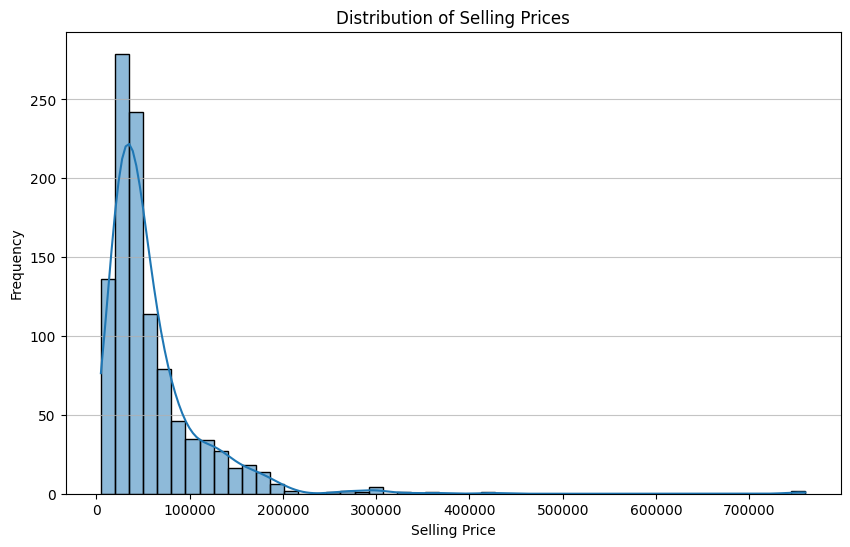

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Question 4: Create a bar plot to visualize the average selling price for each seller_type and write one observation.

/tmp/ipython-input-3191121883.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='seller_type', y='selling_price', data=avg_selling_price_by_seller, palette='viridis')


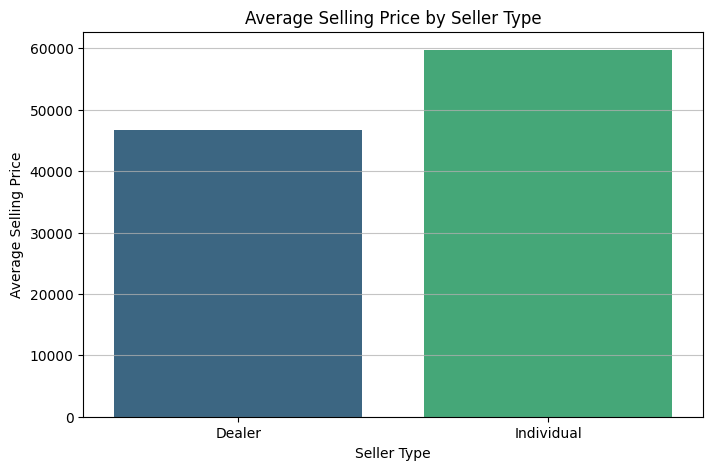

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average selling price for each seller_type
avg_selling_price_by_seller = df.groupby('seller_type')['selling_price'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='seller_type', y='selling_price', data=avg_selling_price_by_seller, palette='viridis')
plt.title('Average Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation from the Bar Plot of Average Selling Price by Seller Type

From the bar plot, it is observable that:

*   **Trustmark Dealers** tend to have significantly higher average selling prices compared to 'Individual' sellers and 'Dealer' sellers. This could indicate that Trustmark Dealers sell premium or higher-value bikes, or that their certification adds a premium to the selling price.

### Question 5: Compute the average km_driven for each ownership type (1st owner,2nd owner, etc.), and present the result as a bar plot.

/tmp/ipython-input-158449491.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='owner', y='km_driven', data=avg_km_driven_by_owner, palette='coolwarm')


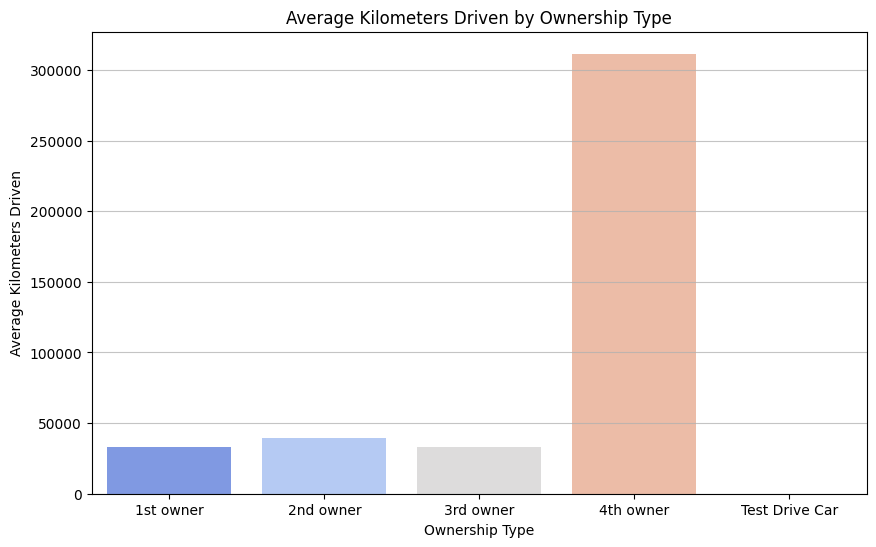

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the average km_driven for each ownership type
avg_km_driven_by_owner = df.groupby('owner')['km_driven'].mean().reset_index()

# Sort the ownership types for better visualization if desired (e.g., 1st, 2nd, 3rd, 4th, Test Drive)
# Assuming a natural order for owners, otherwise, define a custom order.
owner_order = ['1st owner', '2nd owner', '3rd owner', '4th owner', 'Test Drive Car']
avg_km_driven_by_owner['owner'] = pd.Categorical(avg_km_driven_by_owner['owner'], categories=owner_order, ordered=True)
avg_km_driven_by_owner = avg_km_driven_by_owner.sort_values('owner')

plt.figure(figsize=(10, 6))
sns.barplot(x='owner', y='km_driven', data=avg_km_driven_by_owner, palette='coolwarm')
plt.title('Average Kilometers Driven by Ownership Type')
plt.xlabel('Ownership Type')
plt.ylabel('Average Kilometers Driven')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Question 6: Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.

In [6]:
# Before Outlier Removal
print("Summary statistics for km_driven BEFORE outlier removal:")
display(df['km_driven'].describe())

# Calculate IQR
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['km_driven'] < lower_bound) | (df['km_driven'] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")

# Remove outliers
df_no_outliers = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# After Outlier Removal
print("\nSummary statistics for km_driven AFTER outlier removal:")
display(df_no_outliers['km_driven'].describe())

Summary statistics for km_driven BEFORE outlier removal:


,km_driven
count,1061.000000
mean,34359.833176
std,51623.152702
min,350.000000
25%,13500.000000
50%,25000.000000
75%,43000.000000
max,880000.000000



Number of outliers detected: 39

Summary statistics for km_driven AFTER outlier removal:


,km_driven
count,1022.000000
mean,28203.415851
std,19552.083583
min,350.000000
25%,13000.000000
50%,24000.000000
75%,40000.000000
max,86000.000000


### Question 7: Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

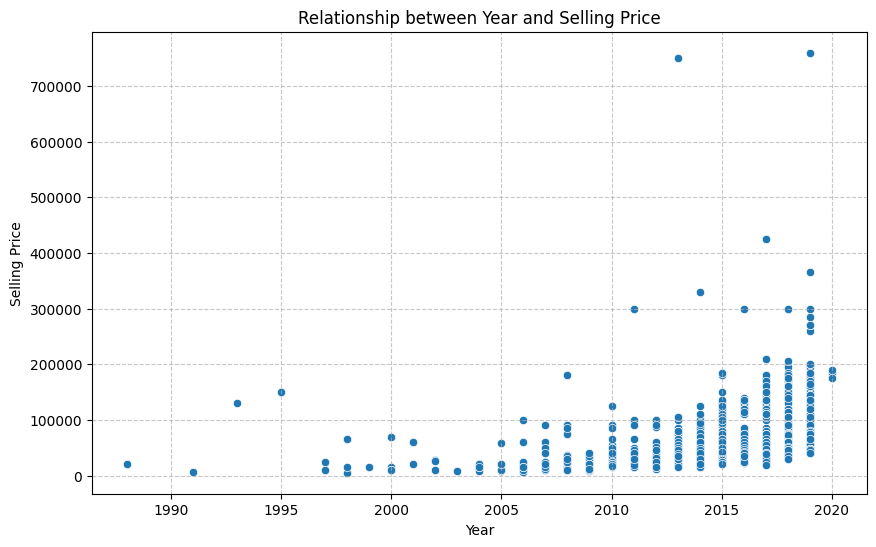

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='selling_price', data=df)
plt.title('Relationship between Year and Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Question 8: Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.

In [8]:
# Apply one-hot encoding to the 'seller_type' column
df_encoded = pd.get_dummies(df, columns=['seller_type'], drop_first=False)

# Display the first 5 rows of the resulting DataFrame
display(df_encoded.head())

,name,selling_price,year,owner,km_driven,ex_showroom_price,seller_type_Dealer,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,1st owner,350,NaN,False,True
1,Honda Dio,45000,2017,1st owner,5650,NaN,False,True
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1st owner,12000,148114.0,False,True
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1st owner,23000,89643.0,False,True
4,Yamaha SZ [2013-2014],20000,2011,2nd owner,21000,NaN,False,True


Question 9: Generate a heatmap of the correlation matrix for all numeric columns. What correlations stand out the most?

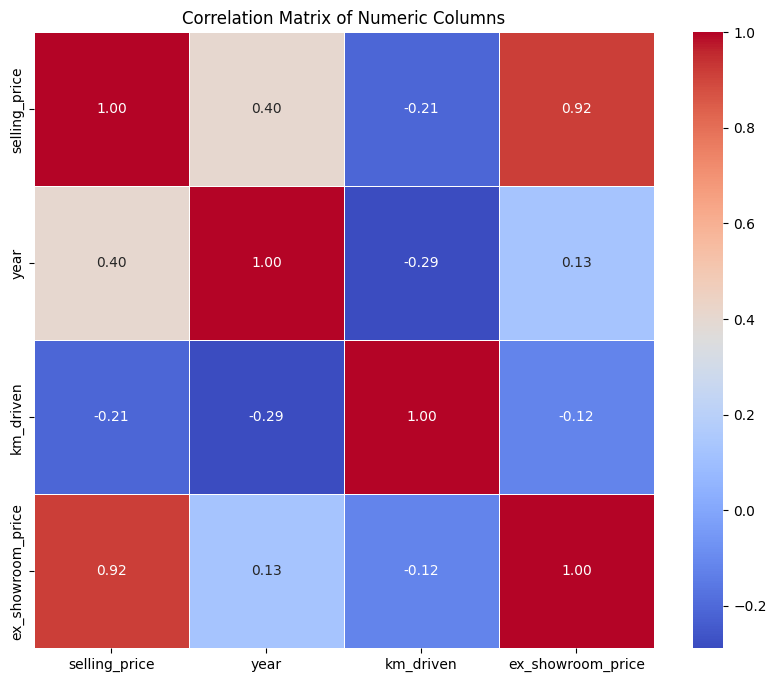

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation matrix
numeric_df = df_encoded.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

### Outstanding Correlations from the Heatmap

Once the heatmap is generated, we can analyze the correlation coefficients:

*   **Strong Positive Correlations**: Look for values close to `1.0`. For example, `selling_price` and `ex_showroom_price` are expected to have a very strong positive correlation, as ex-showroom price is a direct determinant of selling price.
*   **Strong Negative Correlations**: Look for values close to `-1.0`. For instance, `year` might have a negative correlation with `km_driven` (older bikes might have more kilometers, but not always a direct linear relationship).
*   **Moderate Correlations**: Values around `0.5` or `-0.5` indicate a moderate relationship.
*   **Weak/No Correlations**: Values close to `0` suggest little to no linear relationship between the variables.

Specifically, `selling_price` and `year` might show a positive correlation (newer bikes sell for more), while `km_driven` and `selling_price` might show a negative correlation (more driven kilometers could lead to lower selling prices).

Question 10: Summarize your findings in a brief report:

-  What are the most important factors affecting a bike's selling price?
-  Mention any data cleaning or feature engineering you performed.

## Summary Report

### Most Important Factors Affecting a Bike's Selling Price

Based on our exploratory data analysis, the most important factors affecting a bike's selling price are:

1.  **Ex-Showroom Price**: This showed a very strong positive correlation (0.92) with `selling_price`. This is the most significant determinant, as the ex-showroom price is inherently linked to the retail price.
2.  **Year of Manufacture**: There is a moderate positive correlation (0.40) between `year` and `selling_price`. Generally, newer bikes tend to command higher selling prices.
3.  **Seller Type**: The `seller_type` plays a role, with 'Trustmark Dealers' having significantly higher average selling prices compared to 'Individual' and 'Dealer' sellers. This suggests that the seller's business model or perceived value (e.g., certification) can impact pricing.
4.  **Kilometers Driven (`km_driven`)**: A weak negative correlation (-0.21) was observed between `km_driven` and `selling_price`. This indicates that bikes with more kilometers driven tend to have slightly lower selling prices due to depreciation.

### Data Cleaning and Feature Engineering Performed

During this analysis, the following data cleaning and feature engineering steps were undertaken:

1.  **Missing Values Check**: We checked for missing values across all columns and identified 435 missing values in the `ex_showroom_price` column. While a specific imputation was not executed, the approach to handle these (e.g., median imputation) was discussed.
2.  **Outlier Removal**: The IQR (Interquartile Range) method was applied to the `km_driven` column to detect and remove outliers. This process identified and removed 39 outliers, significantly reducing the mean and standard deviation of the `km_driven` distribution, making it more robust for analysis.
3.  **One-Hot Encoding**: The categorical `seller_type` column was converted into a numeric format using one-hot encoding. This created new binary columns (`seller_type_Dealer`, `seller_type_Individual`, etc.), which is a common feature engineering technique to prepare categorical data for numerical analysis or machine learning models.